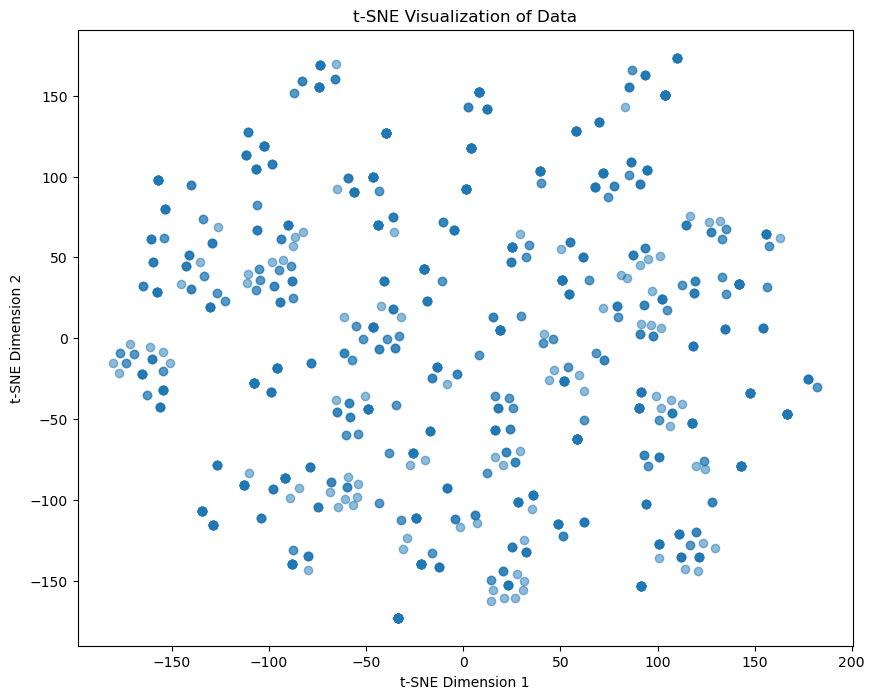

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os
import shutil
from sklearn.cluster import KMeans
import seaborn as sns

# Load the data
data = pd.read_excel('image_stats_no_TF.xlsx')
data_for_tsne = data.drop(columns=['Image Name'])
# Preprocess your data if needed
# For example, handle missing values, encode categorical variables, etc.

# Scale your data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_tsne)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(scaled_data)

# Visualize clusters
plt.figure(figsize=(10, 8))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.5)
plt.title('t-SNE Visualization of Data')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

/Users/vishesh/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


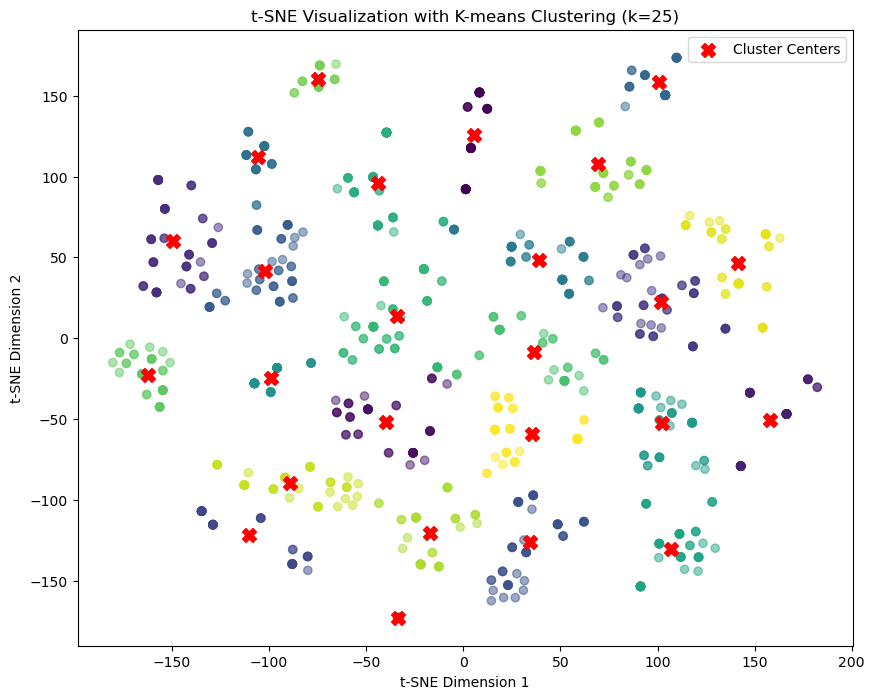

In [5]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=25, random_state=42)
cluster_labels = kmeans.fit_predict(tsne_data)
data['Cluster Label'] = cluster_labels

# Visualize clusters
plt.figure(figsize=(10, 8))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', marker='X', label='Cluster Centers')
plt.title('t-SNE Visualization with K-means Clustering (k=25)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()

In [6]:
data.head()

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Cluster Label
0,0071.jpg,45.170199,84.845348,4,2,254.207548,8.847174,12
1,0717.jpg,39.784124,143.718986,8,2,216.080994,29.997984,21
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,7
3,0065.jpg,50.431992,62.041157,13,4,186.434156,36.924007,20
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,3


In [7]:
i=0
mt = pd.DataFrame()
while (i<25):
  d=data[data['Cluster Label']==i]
  mt.at[i,'Number of Corners']=d['Number of Corners'].mean()
  i=i+1


In [8]:
i=0
while (i<25):
  d=data[data['Cluster Label']==i]
  mt.at[i,'Number of Concave Corners']=d['Number of Concave Corners'].mean()
  i=i+1


In [9]:
i=0
while (i<25):
  d=data[data['Cluster Label']==i]
  mt.at[i,'Std Distance from Centroid']=d['Std Distance from Centroid'].mean()
  i=i+1


In [10]:
i=0
while (i<25):
  d=data[data['Cluster Label']==i]
  mt.at[i,'number of entries']=len(d)
  i=i+1

In [11]:
i=0
while (i<25):

  mt.at[i,'W Sum']=mt.iloc[i,0]*5+mt.iloc[i,1]*10 +mt.iloc[i,2]*0.75
  i=i+1

In [12]:
mt

,Number of Corners,Number of Concave Corners,Std Distance from Centroid,number of entries,W Sum
0,10.204082,0.000000,28.379480,49.0,72.305018
1,6.744681,0.106383,24.423303,47.0,53.104712
2,6.555556,1.200000,61.342970,45.0,90.785005
3,4.000000,0.000000,5.025995,61.0,23.769496
4,10.271186,2.949153,40.152306,59.0,110.961687
5,5.100000,0.400000,2.385209,40.0,31.288907
6,6.561404,1.491228,33.835236,57.0,73.095725
7,4.000000,0.000000,1.822364,53.0,21.366773
8,20.350000,9.025000,47.805445,40.0,227.854084
9,4.000000,0.000000,3.593207,31.0,22.694906


In [13]:
mt.iloc[0,0]

10.204081632653061

In [14]:

i=0
while (i<25):
  a=mt.iloc[i,4]
  if (a<41):
    data.loc[data['Cluster Label']==i,'Complexity']=0

  elif (a>41 and a<91):
    data.loc[data['Cluster Label']==i,'Complexity']=1

  elif (a>91):
    data.loc[data['Cluster Label']==i,'Complexity']=2
  i=i+1

In [15]:
i=0
while (i<3):
  d=data[data['Complexity']==i]
  mt.at[i,'Number of entries']=len(d)
  i=i+1
mt

,Number of Corners,Number of Concave Corners,Std Distance from Centroid,number of entries,W Sum,Number of entries
0,10.204082,0.000000,28.379480,49.0,72.305018,308.0
1,6.744681,0.106383,24.423303,47.0,53.104712,598.0
2,6.555556,1.200000,61.342970,45.0,90.785005,277.0
3,4.000000,0.000000,5.025995,61.0,23.769496,NaN
4,10.271186,2.949153,40.152306,59.0,110.961687,NaN
5,5.100000,0.400000,2.385209,40.0,31.288907,NaN
6,6.561404,1.491228,33.835236,57.0,73.095725,NaN
7,4.000000,0.000000,1.822364,53.0,21.366773,NaN
8,20.350000,9.025000,47.805445,40.0,227.854084,NaN
9,4.000000,0.000000,3.593207,31.0,22.694906,NaN


In [16]:
l = 'E7-images'
destination_base = 'complex'

os.makedirs(destination_base, exist_ok=True)

for i in range(3):
    # Create subdirectories for each category
    category_path = os.path.join(destination_base, str(i))
    os.makedirs(category_path, exist_ok=True)

    # Iterate over the files in the image directory
    for file in os.listdir(l):

        # Filter the DataFrame for the current file
        d = data[data['Image Name'] == file]
        if (d.iloc[0, 8] == i):
            # Copy the file to the corresponding category directory
            shutil.copy(os.path.join(l, file), category_path)

print("Files have been categorized and copied.")

Files have been categorized and copied.


In [17]:
data.head()

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Cluster Label,Complexity
0,0071.jpg,45.170199,84.845348,4,2,254.207548,8.847174,12,1.0
1,0717.jpg,39.784124,143.718986,8,2,216.080994,29.997984,21,1.0
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,7,0.0
3,0065.jpg,50.431992,62.041157,13,4,186.434156,36.924007,20,2.0
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,3,0.0


In [18]:
d = pd.read_excel('image_stats.xlsx')

In [19]:
import numpy as np
d['Cluster Label']=np.nan
d['Complexity']=np.nan
d.head()

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Layout Area,Height of TF Box,Width of TF Box,Cluster Label,Complexity
0,0071.jpg,45.170199,84.845348,4,2,254.207548,8.847174,130779.5,452.015411,337.649902,NaN,NaN
1,0717.jpg,39.784124,143.718986,8,2,216.080994,29.997984,96694.5,336.609161,452.846588,NaN,NaN
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,146617.0,450.278595,329.235260,NaN,NaN
3,0065.jpg,50.431992,62.041157,13,4,186.434156,36.924007,108172.5,454.893829,322.203217,NaN,NaN
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,147924.5,453.092133,334.324768,NaN,NaN


In [20]:
i=0
while (i<1183):
  d.iloc[i,10]=data.iloc[i,7]
  d.iloc[i,11]=data.iloc[i,8]

  i=i+1

In [21]:
d.head()

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Layout Area,Height of TF Box,Width of TF Box,Cluster Label,Complexity
0,0071.jpg,45.170199,84.845348,4,2,254.207548,8.847174,130779.5,452.015411,337.649902,12.0,1.0
1,0717.jpg,39.784124,143.718986,8,2,216.080994,29.997984,96694.5,336.609161,452.846588,21.0,1.0
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,146617.0,450.278595,329.235260,7.0,0.0
3,0065.jpg,50.431992,62.041157,13,4,186.434156,36.924007,108172.5,454.893829,322.203217,20.0,2.0
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,147924.5,453.092133,334.324768,3.0,0.0


In [22]:
excel_file_path = 'outputfinals.xlsx'  # Specify the file path where you want to save the Excel file
d.to_excel(excel_file_path, index=False)

In [23]:
mt

,Number of Corners,Number of Concave Corners,Std Distance from Centroid,number of entries,W Sum,Number of entries
0,10.204082,0.000000,28.379480,49.0,72.305018,308.0
1,6.744681,0.106383,24.423303,47.0,53.104712,598.0
2,6.555556,1.200000,61.342970,45.0,90.785005,277.0
3,4.000000,0.000000,5.025995,61.0,23.769496,NaN
4,10.271186,2.949153,40.152306,59.0,110.961687,NaN
5,5.100000,0.400000,2.385209,40.0,31.288907,NaN
6,6.561404,1.491228,33.835236,57.0,73.095725,NaN
7,4.000000,0.000000,1.822364,53.0,21.366773,NaN
8,20.350000,9.025000,47.805445,40.0,227.854084,NaN
9,4.000000,0.000000,3.593207,31.0,22.694906,NaN


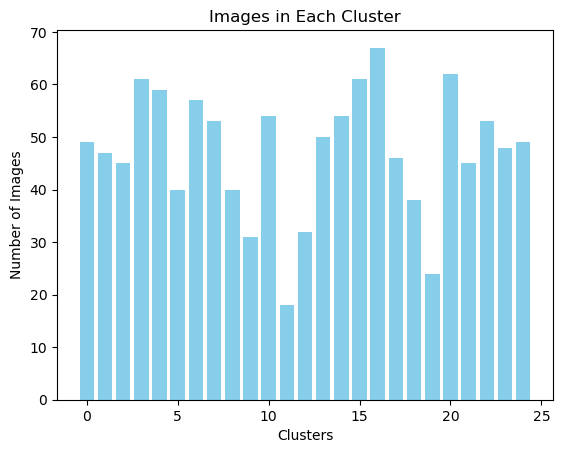

In [24]:
categories=np.linspace(0,24,25)
plt.bar(categories, mt['number of entries'], color='skyblue')

# Add labels and title
plt.xlabel('Clusters')
plt.ylabel('Number of Images')
plt.title('Images in Each Cluster')

# Show plot
plt.show()

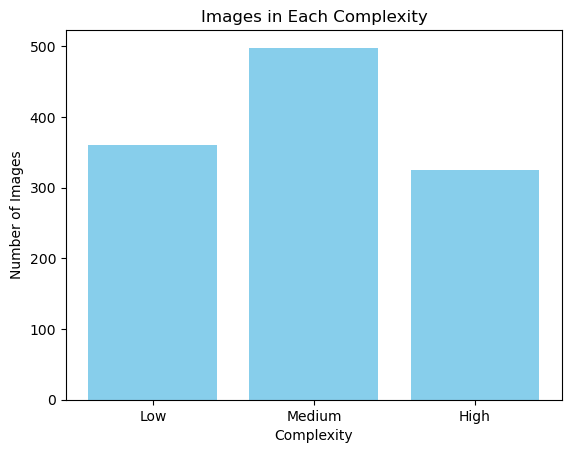

In [25]:
categories=['Low','Medium','High']
plt.bar(categories, [360,498,325], color='skyblue')

# Add labels and title
plt.xlabel('Complexity')
plt.ylabel('Number of Images')
plt.title('Images in Each Complexity')

# Show plot
plt.show()

In [26]:
d0=data[data['Complexity']==0]
d1=data[data['Complexity']==1]
d2=data[data['Complexity']==2]

In [27]:
d0.head()

,Image Name,Std of Angles,Std of Sides,Number of Corners,Number of Concave Corners,Avg Distance from Centroid,Std Distance from Centroid,Cluster Label,Complexity
2,0703.jpg,0.595572,59.557195,4,0,272.872781,2.048222,7,0.0
4,0059.jpg,1.117977,56.906069,4,0,273.533744,2.406484,3,0.0
13,0529.jpg,23.807515,157.055718,5,0,274.521784,2.321608,5,0.0
17,0461.jpg,1.117977,56.906069,4,0,273.533744,2.406484,3,0.0
21,0475.jpg,1.523158,57.805091,4,0,274.578318,3.201138,3,0.0


In [28]:
m=pd.DataFrame()

In [29]:
print('Average number of corners for low complexity is',d0['Number of Corners'].mean())
print('Average number of corners for medium complexity is',d1['Number of Corners'].mean())
print('Average number of corners for high complexity is',d2['Number of Corners'].mean())
m.at[0,'Average number of corners']=d0['Number of Corners'].mean()
m.at[1,'Average number of corners']=d1['Number of Corners'].mean()
m.at[2,'Average number of corners']=d2['Number of Corners'].mean()

Average number of corners for low complexity is 4.087662337662338
Average number of corners for medium complexity is 6.854515050167224
Average number of corners for high complexity is 12.31768953068592


In [30]:
print('Average number of concave corners for low complexity is',d0['Number of Concave Corners'].mean())
print('Average number of concave corners for medium complexity is',d1['Number of Concave Corners'].mean())
print('Average number of concave corners for high complexity is',d2['Number of Concave Corners'].mean())
m.at[0,'Average number of concave corners']=d0['Number of Concave Corners'].mean()
m.at[1,'Average number of concave corners']=d1['Number of Concave Corners'].mean()
m.at[2,'Average number of concave corners']=d2['Number of Concave Corners'].mean()

Average number of concave corners for low complexity is 0.05194805194805195
Average number of concave corners for medium complexity is 0.9632107023411371
Average number of concave corners for high complexity is 3.7545126353790614


In [31]:
print('Average Standard Deviation of angles for low complexity is',d0['Std of Angles'].mean())
print('Average Standard Deviation of angles for medium complexity is',d1['Std of Angles'].mean())
print('Average Standard Deviation of angles for high complexity is',d2['Std of Angles'].mean())
m.at[0,'Average Standard Deviation of angles']=d0['Std of Angles'].mean()
m.at[1,'Average Standard Deviation of angles']=d1['Std of Angles'].mean()
m.at[2,'Average Standard Deviation of angles']=d2['Std of Angles'].mean()

Average Standard Deviation of angles for low complexity is 8.655837129340373
Average Standard Deviation of angles for medium complexity is 43.749709028401604
Average Standard Deviation of angles for high complexity is 59.37695763158018


In [32]:

print('Average Standard Deviation of side length for low complexity is',d0['Std of Sides'].mean())
print('Average Standard Deviation of side length for medium complexity is',d1['Std of Sides'].mean())
print('Average Standard Deviation of side length for high complexity is',d2['Std of Sides'].mean())
m.at[0,'Average Standard Deviation of side length']=d0['Std of Sides'].mean()
m.at[1,'Average Standard Deviation of side length']=d1['Std of Sides'].mean()
m.at[2,'Average Standard Deviation of side length']=d2['Std of Sides'].mean()

Average Standard Deviation of side length for low complexity is 75.75268780353447
Average Standard Deviation of side length for medium complexity is 109.42802608665448
Average Standard Deviation of side length for high complexity is 97.56190233995937


In [33]:
print('Average Standard Deviation of distance form centroid for low complexity is',d0['Std Distance from Centroid'].mean())
print('Average Standard Deviation of distance from centroid for medium complexity is',d1['Std Distance from Centroid'].mean())
print('Average Standard Deviation of distance from centroid for high complexity is',d2['Std Distance from Centroid'].mean())
m.at[0,'Average Standard Deviation of distance from centroid']=d0['Std Distance from Centroid'].mean()
m.at[1,'Average Standard Deviation of distance from centroid']=d1['Std Distance from Centroid'].mean()
m.at[2,'Average Standard Deviation of distance from centroid']=d2['Std Distance from Centroid'].mean()

Average Standard Deviation of distance form centroid for low complexity is 7.512270582469839
Average Standard Deviation of distance from centroid for medium complexity is 33.858441332902764
Average Standard Deviation of distance from centroid for high complexity is 44.7412729702908


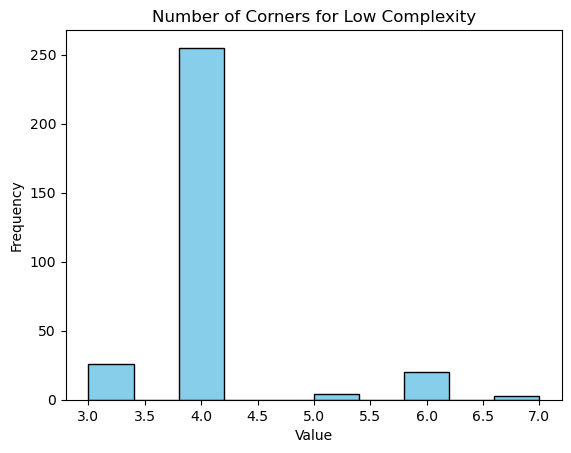

In [34]:
plt.hist(d0['Number of Corners'], bins=10, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Corners for Low Complexity')

# Show plot
plt.show()

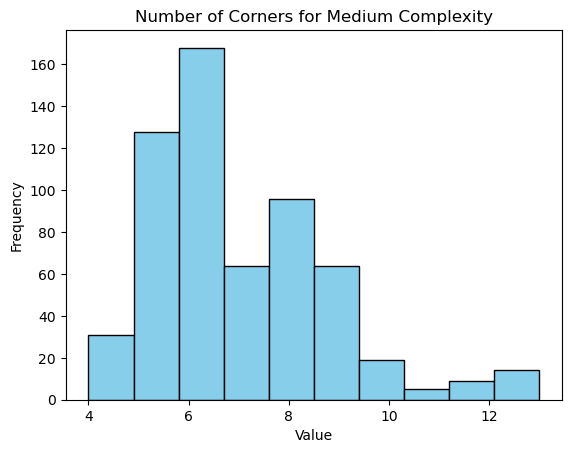

In [35]:
plt.hist(d1['Number of Corners'], bins=10, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Corners for Medium Complexity')

# Show plot
plt.show()

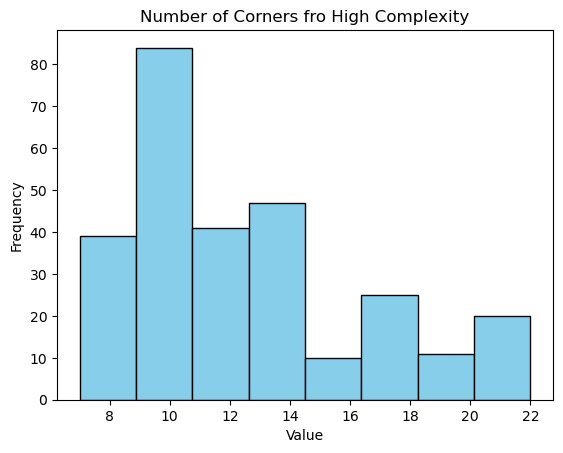

In [36]:
plt.hist(d2['Number of Corners'], bins=8, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Corners fro High Complexity')

# Show plot
plt.show()

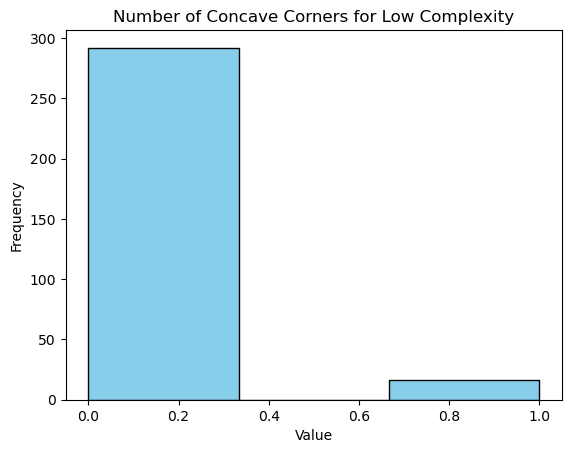

In [37]:
plt.hist(d0['Number of Concave Corners'], bins=3, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Concave Corners for Low Complexity')

# Show plot
plt.show()

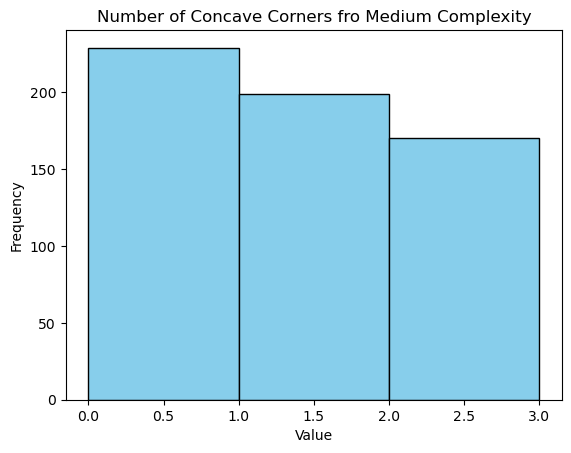

In [39]:
plt.hist(d1['Number of Concave Corners'], bins=3, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Concave Corners fro Medium Complexity')

# Show plot
plt.show()

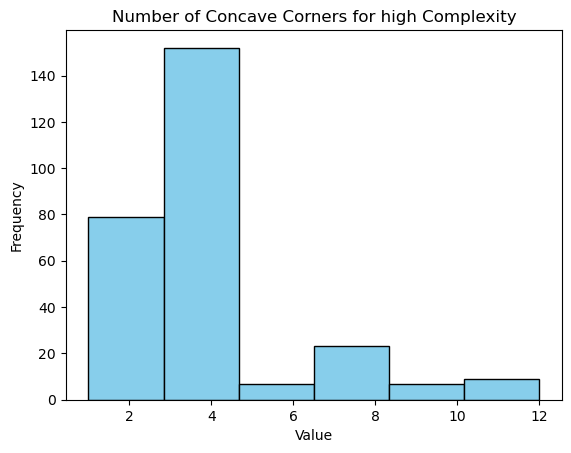

In [40]:
plt.hist(d2['Number of Concave Corners'], bins=6, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Number of Concave Corners for high Complexity')

# Show plot
plt.show()

In [41]:
m

,Average number of corners,Average number of concave corners,Average Standard Deviation of angles,Average Standard Deviation of side length,Average Standard Deviation of distance from centroid
0,4.087662,0.051948,8.655837,75.752688,7.512271
1,6.854515,0.963211,43.749709,109.428026,33.858441
2,12.317690,3.754513,59.376958,97.561902,44.741273
